In [1]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

In [12]:
safe_root = Path(
    r"C:\Users\karth\Desktop\GeoSentinel-AI\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"
)

r10m = list(safe_root.glob("GRANULE/*/IMG_DATA/R10m"))[0]

print(r10m)

C:\Users\karth\Desktop\GeoSentinel-AI\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m


In [13]:
for file in r10m.glob("*.jp2"):
    print(file.name)

T43QHV_20260601T050649_AOT_10m.jp2
T43QHV_20260601T050649_B02_10m.jp2
T43QHV_20260601T050649_B03_10m.jp2
T43QHV_20260601T050649_B04_10m.jp2
T43QHV_20260601T050649_B08_10m.jp2
T43QHV_20260601T050649_TCI_10m.jp2
T43QHV_20260601T050649_WVP_10m.jp2


In [14]:
red_file = [f for f in r10m.glob("*B04*.jp2")][0]

red_ds = rasterio.open(red_file)

print(red_ds.profile)

{'driver': 'JP2OpenJPEG', 'dtype': 'uint16', 'nodata': None, 'width': 10980, 'height': 10980, 'count': 1, 'crs': None, 'transform': Affine(10.0, 0.0, 799980.0,
       0.0, -10.0, 2000040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True}


In [15]:
red = red_ds.read(1)

print(red.shape)
print(red.dtype)

(10980, 10980)
uint16


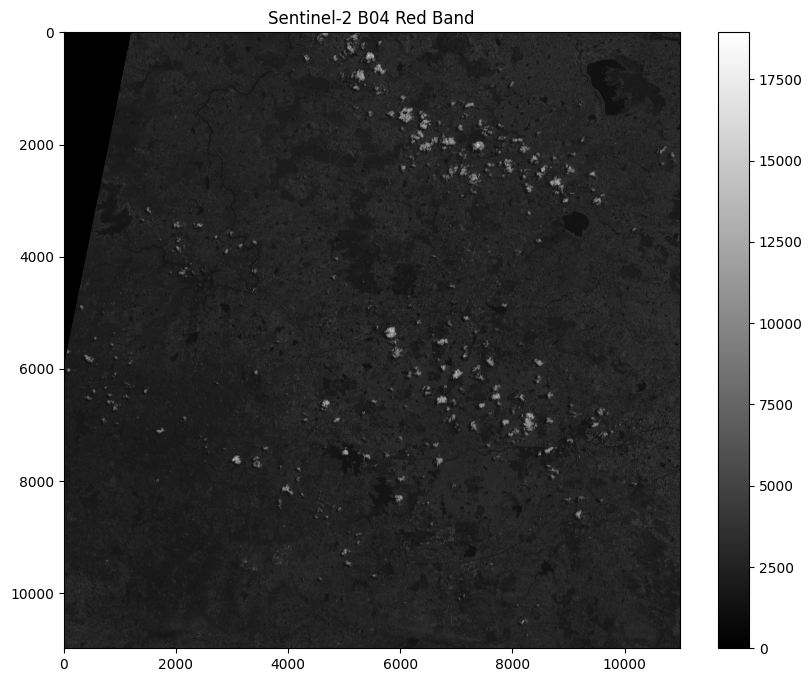

In [16]:
plt.figure(figsize=(10,8))

plt.imshow(red, cmap="gray")

plt.title("Sentinel-2 B04 Red Band")

plt.colorbar()

plt.show()

In [17]:
nir_file = [f for f in r10m.glob("*B08*.jp2")][0]

nir_ds = rasterio.open(nir_file)

nir = nir_ds.read(1)

print(nir.shape)

(10980, 10980)


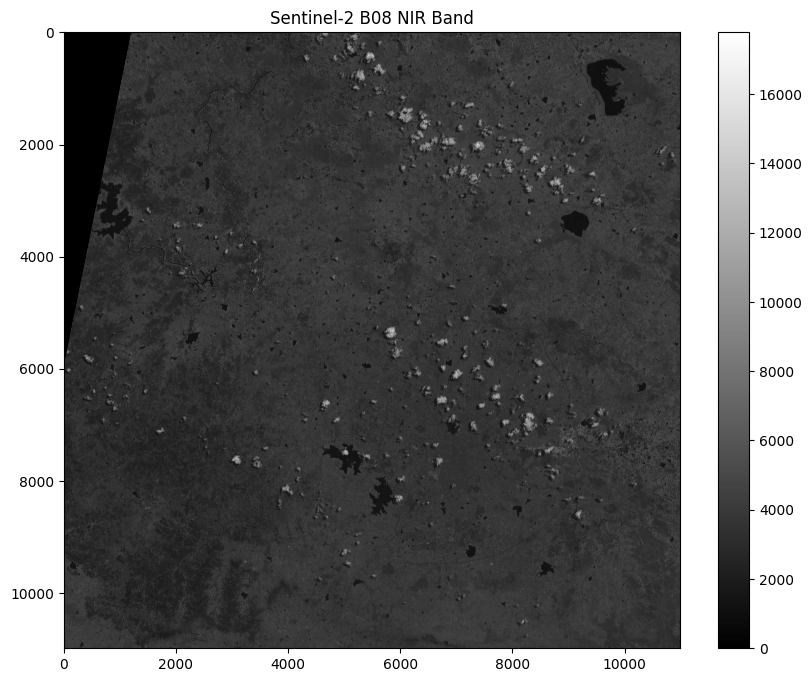

In [18]:
plt.figure(figsize=(10,8))

plt.imshow(nir, cmap="gray")

plt.title("Sentinel-2 B08 NIR Band")

plt.colorbar()

plt.show()

In [19]:
print("CRS:", red_ds.crs)
print("Bounds:", red_ds.bounds)
print("Resolution:", red_ds.res)
print("Width:", red_ds.width)
print("Height:", red_ds.height)

CRS: None
Bounds: BoundingBox(left=799980.0, bottom=1890240.0, right=909780.0, top=2000040.0)
Resolution: (10.0, 10.0)
Width: 10980
Height: 10980


In [20]:
print("Red Mean:", np.mean(red))
print("NIR Mean:", np.mean(nir))

print("Red Max:", np.max(red))
print("NIR Max:", np.max(nir))

Red Mean: 2575.938679848441
NIR Mean: 3582.3376700475446
Red Max: 18949
NIR Max: 17787


In [21]:
print("""
SAFE Product
 ↓
B04 (Red)
 ↓
B08 (NIR)
 ↓
NDVI
 ↓
Vegetation Analysis
 ↓
GeoSentinel AI
""")


SAFE Product
 ↓
B04 (Red)
 ↓
B08 (NIR)
 ↓
NDVI
 ↓
Vegetation Analysis
 ↓
GeoSentinel AI

